# Retail Sales Analysis — Python + SQL + pandas

This notebook builds a small, deterministic demo Northwind-shaped SQLite database,
runs the analytical queries (SQLite dialect), and renders charts.

> Self-contained — no external download. Swap `build_demo_db()` for a real Northwind
> connection to use real data. Demo data is seeded (`rng = 42`) so output is reproducible.


In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Build a deterministic demo database (Northwind-shaped)

In [2]:
def build_demo_db():
    rng = np.random.default_rng(42)
    con = sqlite3.connect(":memory:")
    cur = con.cursor()
    cur.executescript("""
        CREATE TABLE Categories  (CategoryID INTEGER, CategoryName TEXT);
        CREATE TABLE Suppliers   (SupplierID INTEGER, SupplierName TEXT);
        CREATE TABLE Products    (ProductID INTEGER, ProductName TEXT,
                                  CategoryID INTEGER, SupplierID INTEGER, Price REAL);
        CREATE TABLE Customers   (CustomerID INTEGER, CustomerName TEXT);
        CREATE TABLE Employees   (EmployeeID INTEGER, FirstName TEXT, LastName TEXT);
        CREATE TABLE Orders      (OrderID INTEGER, CustomerID INTEGER,
                                  EmployeeID INTEGER, OrderDate TEXT);
        CREATE TABLE OrderDetails(OrderDetailID INTEGER, OrderID INTEGER,
                                  ProductID INTEGER, Quantity INTEGER);
    """)
    categories = ["Beverages","Condiments","Confections","Dairy",
                  "Grains","Meat","Produce","Seafood"]
    cur.executemany("INSERT INTO Categories VALUES (?,?)",
                    [(i+1,n) for i,n in enumerate(categories)])
    suppliers = [f"Supplier {chr(65+i)}" for i in range(10)]
    cur.executemany("INSERT INTO Suppliers VALUES (?,?)",
                    [(i+1,n) for i,n in enumerate(suppliers)])
    products = []
    for pid in range(1,41):
        products.append((pid, f"Product {pid:02d}",
                         int(rng.integers(1,len(categories)+1)),
                         int(rng.integers(1,len(suppliers)+1)),
                         round(float(rng.uniform(5,120)),2)))
    cur.executemany("INSERT INTO Products VALUES (?,?,?,?,?)", products)
    cur.executemany("INSERT INTO Customers VALUES (?,?)",
                    [(i+1,f"Customer {i+1:02d}") for i in range(25)])
    cur.executemany("INSERT INTO Employees VALUES (?,?,?)",
                    [(1,"Anna","Petrova"),(2,"Bolat","Kim"),(3,"Chen","Wei"),
                     (4,"Dana","Sultan"),(5,"Erik","Nurlan")])
    orders, details, od_id = [], [], 1
    for oid in range(1,601):
        month = int(rng.choice(range(1,13),
                    p=np.array([6,6,7,7,8,8,7,7,8,9,11,16])/100))
        orders.append((oid, int(rng.integers(1,26)), int(rng.integers(1,6)),
                       f"2023-{month:02d}-{int(rng.integers(1,28)):02d}"))
        for _ in range(int(rng.integers(1,5))):
            details.append((od_id, oid, int(rng.integers(1,41)),
                            int(rng.integers(1,30))))
            od_id += 1
    cur.executemany("INSERT INTO Orders VALUES (?,?,?,?)", orders)
    cur.executemany("INSERT INTO OrderDetails VALUES (?,?,?,?)", details)
    con.commit()
    return con

con = build_demo_db()
print("demo database ready")

demo database ready


## 2. Monthly revenue trend (Challenge 5)

Grouped by month; in real Northwind, group by **year and month together** so equal
months across years don't collapse. Seasonality is the business signal here.

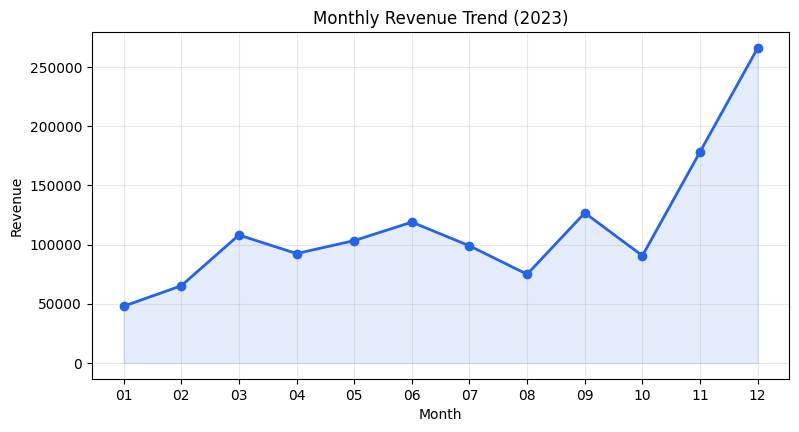

In [3]:
q = """
    SELECT strftime('%m', o.OrderDate) AS month,
           SUM(p.Price * od.Quantity)  AS revenue
    FROM Orders o
    JOIN OrderDetails od ON od.OrderID  = o.OrderID
    JOIN Products     p  ON p.ProductID = od.ProductID
    GROUP BY month ORDER BY month;
"""
df = pd.read_sql(q, con)
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(df["month"], df["revenue"], marker="o", linewidth=2, color="#2563eb")
ax.fill_between(df["month"], df["revenue"], alpha=0.12, color="#2563eb")
ax.set_title("Monthly Revenue Trend (2023)")
ax.set_xlabel("Month"); ax.set_ylabel("Revenue"); ax.grid(True, alpha=0.3)
plt.show()

## 3. Category revenue vs. average (Challenge 1)

The dashed line is the average category revenue. Bars above it are the *significant set*
the `HAVING` filter keeps — the filter scopes, it doesn't pick the leader.

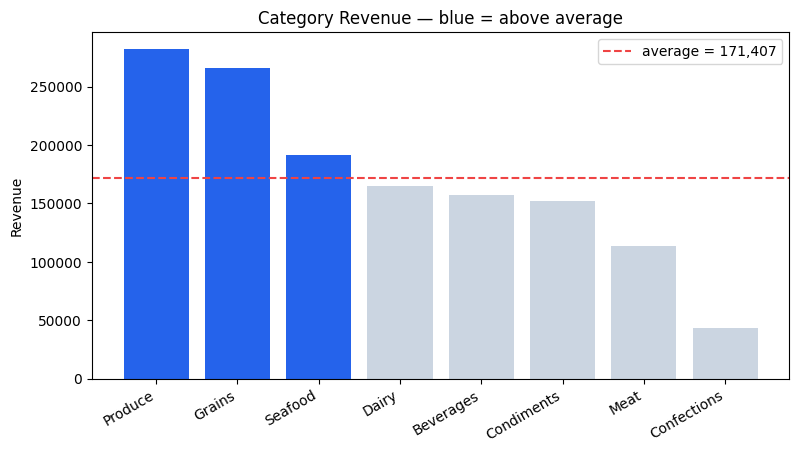

In [4]:
q = """
    SELECT c.CategoryName AS category, SUM(p.Price*od.Quantity) AS revenue
    FROM Categories c
    JOIN Products p ON p.CategoryID = c.CategoryID
    JOIN OrderDetails od ON od.ProductID = p.ProductID
    GROUP BY c.CategoryName ORDER BY revenue DESC;
"""
df = pd.read_sql(q, con)
avg = df["revenue"].mean()
colors = ["#2563eb" if v>avg else "#cbd5e1" for v in df["revenue"]]
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(df["category"], df["revenue"], color=colors)
ax.axhline(avg, color="#ef4444", ls="--", lw=1.5, label=f"average = {avg:,.0f}")
ax.set_title("Category Revenue — blue = above average"); ax.set_ylabel("Revenue")
ax.legend(); plt.xticks(rotation=30, ha="right"); plt.show()

## 4. Customer segments by quantile (Final / CLV)

Instead of round-number cutoffs (10000 / 5000), boundaries are set by **quantiles**:
top 20% = High. This is robust to growth and inflation.

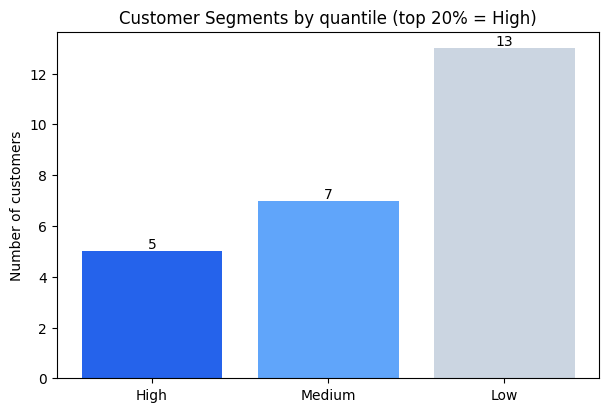

In [5]:
q = """
    SELECT c.CustomerName AS customer, SUM(p.Price*od.Quantity) AS revenue
    FROM Customers c
    JOIN Orders o ON o.CustomerID = c.CustomerID
    JOIN OrderDetails od ON od.OrderID = o.OrderID
    JOIN Products p ON p.ProductID = od.ProductID
    GROUP BY c.CustomerID, c.CustomerName;
"""
df = pd.read_sql(q, con)
df["segment"] = pd.qcut(df["revenue"], q=[0,0.5,0.8,1.0],
                        labels=["Low","Medium","High"])
counts = df["segment"].value_counts().reindex(["High","Medium","Low"])
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(counts.index, counts.values, color=["#2563eb","#60a5fa","#cbd5e1"])
ax.set_title("Customer Segments by quantile (top 20% = High)")
ax.set_ylabel("Number of customers")
for i,v in enumerate(counts.values): ax.text(i, v+0.1, str(int(v)), ha="center")
plt.show()

con.close()